# Porovnanie Výsledkov Modelov

Analýza a porovnanie výsledkov všetkých 4 kombinácií:
- TESS + MLP
- TESS + CNN
- CREMA-D + MLP
- CREMA-D + CNN

In [6]:
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Pridaj projekt root
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import Config

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Načítaj summary metriky

In [7]:
summary_path = Config.OUTPUTS_DIR / "summary_metrics.json"

if not summary_path.exists():
    print(f"❌ Súbor nenájdený: {summary_path}")
    print("Spustite najprv: python run.py --dataset all --model all")
else:
    with open(summary_path, 'r') as f:
        summary = json.load(f)
    
    print(f"✓ Metriky načítané z {summary_path}")
    print(f"\nModely:")
    for model_name in summary['results'].keys():
        print(f"  - {model_name}")

✓ Metriky načítané z C:\Users\zbura\Documents\GitHub\ns-projekt-dsrs\projekt\outputs\summary_metrics.json

Modely:
  - tess_mlp
  - tess_cnn
  - cremad_mlp
  - cremad_cnn


## 2. Tabuľka všetkých metrík

In [8]:
# Vytvorenie DataFrame-u pre všetky metriky
metrics_data = []

for model_name, metrics in summary['results'].items():
    row = {
        'Model': model_name,
        'Accuracy': metrics.get('accuracy', 0),
        'Precision': metrics.get('precision', 0),
        'Recall': metrics.get('recall', 0),
        'F1': metrics.get('f1', 0),
        'ROC-AUC': metrics.get('roc_auc', 0),
    }
    metrics_data.append(row)

df_metrics = pd.DataFrame(metrics_data).set_index('Model')

print("\n=== METRIKY VŠETKÝCH MODELOV ===")
print(df_metrics.to_string())
print(f"\nVlastnosti:{df_metrics.round(4).to_markdown()}")


=== METRIKY VŠETKÝCH MODELOV ===
            Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                        
tess_mlp    0.996875   1.000000  0.995313  0.997651  0.999980
tess_cnn    1.000000   1.000000  1.000000  1.000000  1.000000
cremad_mlp  0.697784   0.715589  0.925270  0.807033  0.679822
cremad_cnn  0.771659   0.771451  0.945919  0.849823  0.836304

Vlastnosti:| Model      |   Accuracy |   Precision |   Recall |     F1 |   ROC-AUC |
|:-----------|-----------:|------------:|---------:|-------:|----------:|
| tess_mlp   |     0.9969 |      1      |   0.9953 | 0.9977 |    1      |
| tess_cnn   |     1      |      1      |   1      | 1      |    1      |
| cremad_mlp |     0.6978 |      0.7156 |   0.9253 | 0.807  |    0.6798 |
| cremad_cnn |     0.7717 |      0.7715 |   0.9459 | 0.8498 |    0.8363 |


## 3. Porovnanie Accuracy

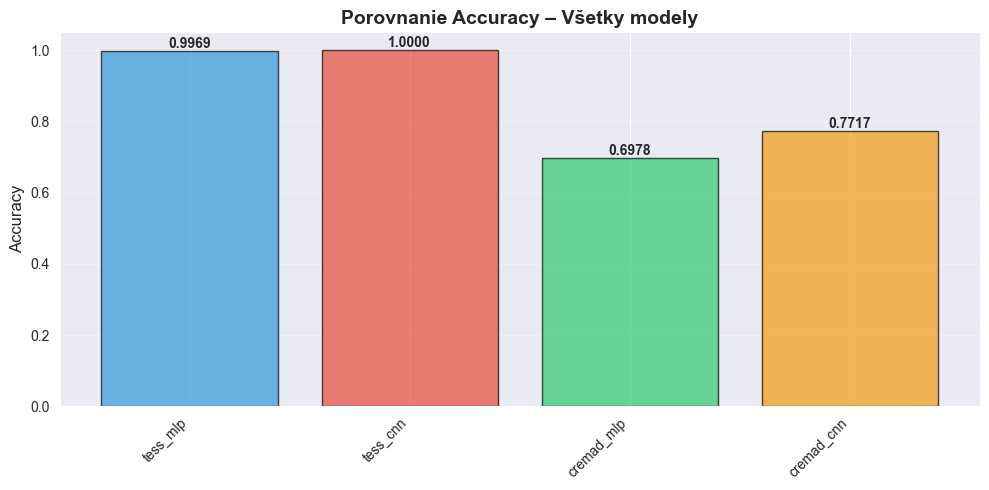

In [9]:
# Accuracy porovnanie
fig, ax = plt.subplots(figsize=(10, 5))

models = df_metrics.index.tolist()
accuracy_values = df_metrics['Accuracy'].values

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = ax.bar(models, accuracy_values, color=colors, alpha=0.7, edgecolor='black')

# Pridaj hodnoty na stĺpce
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Porovnanie Accuracy – Všetky modely', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Porovnanie všetkých metrík (radar chart)

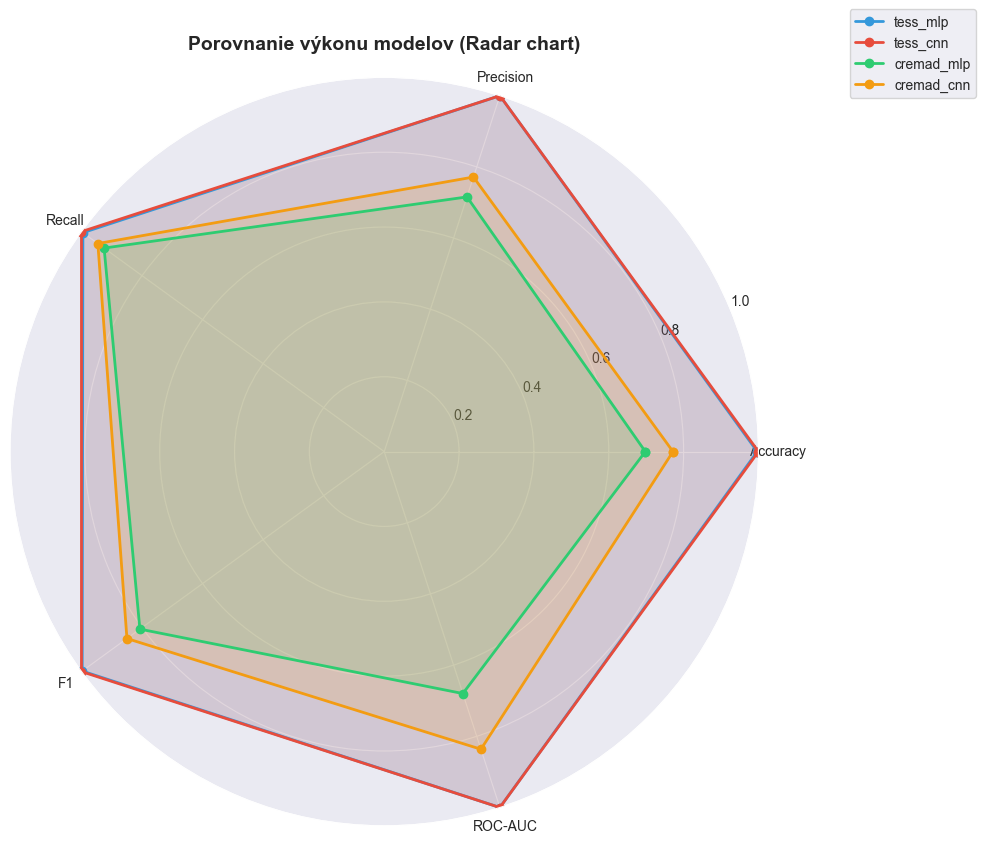

In [10]:
import numpy as np
from math import pi

# Metriky na porovnanie
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
N = len(metrics_to_plot)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Uzavri polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (model_name, color) in enumerate(zip(df_metrics.index, colors)):
    values = df_metrics.loc[model_name, metrics_to_plot].values.tolist()
    values += values[:1]  # Uzavri polygon
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot, size=10)
ax.set_ylim(0, 1)
ax.set_title('Porovnanie výkonu modelov (Radar chart)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Porovnanie Dataset vs Model

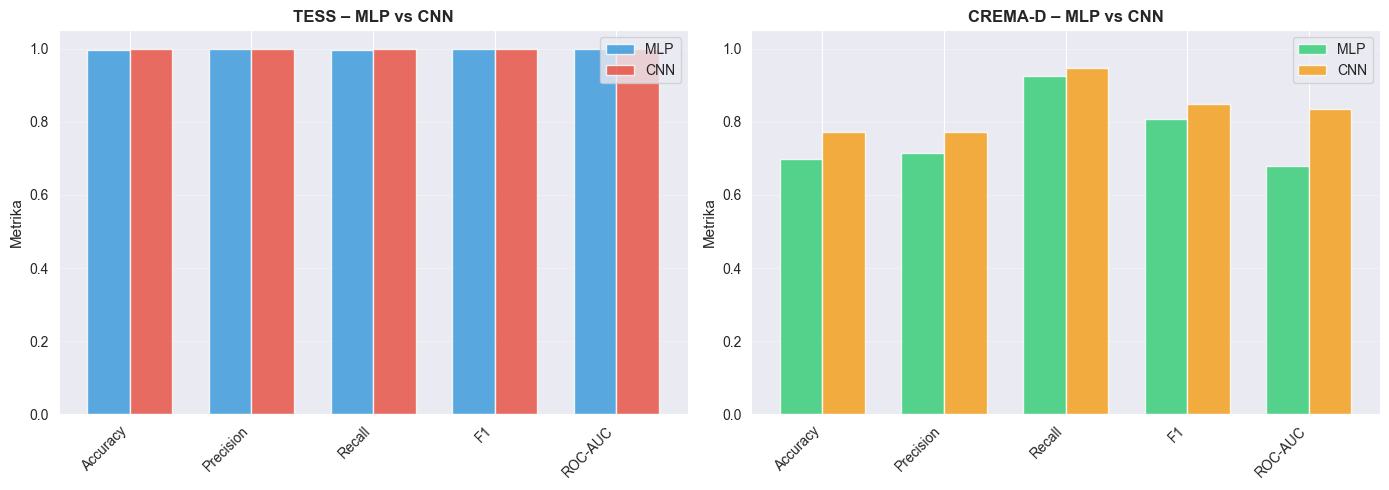

In [11]:
# Reorganizácia dát podľa datasetu
tess_mlp = df_metrics.loc['tess_mlp']
tess_cnn = df_metrics.loc['tess_cnn']
cremad_mlp = df_metrics.loc['cremad_mlp']
cremad_cnn = df_metrics.loc['cremad_cnn']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TESS
x_pos = np.arange(len(metrics_to_plot))
width = 0.35

tess_values = [tess_mlp['Accuracy'], tess_mlp['Precision'], tess_mlp['Recall'], tess_mlp['F1'], tess_mlp['ROC-AUC']]
tess_cnn_values = [tess_cnn['Accuracy'], tess_cnn['Precision'], tess_cnn['Recall'], tess_cnn['F1'], tess_cnn['ROC-AUC']]

axes[0].bar(x_pos - width/2, tess_values, width, label='MLP', color='#3498db', alpha=0.8)
axes[0].bar(x_pos + width/2, tess_cnn_values, width, label='CNN', color='#e74c3c', alpha=0.8)

axes[0].set_ylabel('Metrika', fontsize=11)
axes[0].set_title('TESS – MLP vs CNN', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# CREMA-D
cremad_values = [cremad_mlp['Accuracy'], cremad_mlp['Precision'], cremad_mlp['Recall'], cremad_mlp['F1'], cremad_mlp['ROC-AUC']]
cremad_cnn_values = [cremad_cnn['Accuracy'], cremad_cnn['Precision'], cremad_cnn['Recall'], cremad_cnn['F1'], cremad_cnn['ROC-AUC']]

axes[1].bar(x_pos - width/2, cremad_values, width, label='MLP', color='#2ecc71', alpha=0.8)
axes[1].bar(x_pos + width/2, cremad_cnn_values, width, label='CNN', color='#f39c12', alpha=0.8)

axes[1].set_ylabel('Metrika', fontsize=11)
axes[1].set_title('CREMA-D – MLP vs CNN', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Zhodnotenie a zistenia

In [12]:
print("\n=== ZHODNOTENIE VÝSLEDKOV ===")
print("\n1️⃣  TESS Dataset:")
print(f"   - MLP: Accuracy = {tess_mlp['Accuracy']:.4f}, ROC-AUC = {tess_mlp['ROC-AUC']:.4f}")
print(f"   - CNN: Accuracy = {tess_cnn['Accuracy']:.4f}, ROC-AUC = {tess_cnn['ROC-AUC']:.4f}")
print(f"   ✓ Názor: {'CNN je lepší' if tess_cnn['Accuracy'] > tess_mlp['Accuracy'] else 'MLP je lepší'}")

print("\n2️⃣  CREMA-D Dataset:")
print(f"   - MLP: Accuracy = {cremad_mlp['Accuracy']:.4f}, ROC-AUC = {cremad_mlp['ROC-AUC']:.4f}")
print(f"   - CNN: Accuracy = {cremad_cnn['Accuracy']:.4f}, ROC-AUC = {cremad_cnn['ROC-AUC']:.4f}")
print(f"   ✓ Názor: {'CNN je lepší' if cremad_cnn['Accuracy'] > cremad_mlp['Accuracy'] else 'MLP je lepší'}")

print("\n3️⃣  Dataset Porovnanie:")
tess_avg = (tess_mlp['Accuracy'] + tess_cnn['Accuracy']) / 2
cremad_avg = (cremad_mlp['Accuracy'] + cremad_cnn['Accuracy']) / 2
print(f"   - TESS (priemer): {tess_avg:.4f}")
print(f"   - CREMA-D (priemer): {cremad_avg:.4f}")
print(f"   ✓ TESS je {'ľahší' if tess_avg > cremad_avg else 'ťažší'} na detekciu")

print("\n4️⃣  Model Porovnanie:")
mlp_avg = (tess_mlp['Accuracy'] + cremad_mlp['Accuracy']) / 2
cnn_avg = (tess_cnn['Accuracy'] + cremad_cnn['Accuracy']) / 2
print(f"   - MLP (priemer): {mlp_avg:.4f}")
print(f"   - CNN (priemer): {cnn_avg:.4f}")
print(f"   ✓ {'CNN' if cnn_avg > mlp_avg else 'MLP'} je vo všeobecnosti lepší")

print("\n5️⃣  Najlepší model:")
best_model = df_metrics['Accuracy'].idxmax()
best_acc = df_metrics.loc[best_model, 'Accuracy']
print(f"   🏆 {best_model.upper()} s Accuracy = {best_acc:.4f}")


=== ZHODNOTENIE VÝSLEDKOV ===

1️⃣  TESS Dataset:
   - MLP: Accuracy = 0.9969, ROC-AUC = 1.0000
   - CNN: Accuracy = 1.0000, ROC-AUC = 1.0000
   ✓ Názor: CNN je lepší

2️⃣  CREMA-D Dataset:
   - MLP: Accuracy = 0.6978, ROC-AUC = 0.6798
   - CNN: Accuracy = 0.7717, ROC-AUC = 0.8363
   ✓ Názor: CNN je lepší

3️⃣  Dataset Porovnanie:
   - TESS (priemer): 0.9984
   - CREMA-D (priemer): 0.7347
   ✓ TESS je ľahší na detekciu

4️⃣  Model Porovnanie:
   - MLP (priemer): 0.8473
   - CNN (priemer): 0.8858
   ✓ CNN je vo všeobecnosti lepší

5️⃣  Najlepší model:
   🏆 TESS_CNN s Accuracy = 1.0000
